# 03: Modelling and Prediction

This notebook covers the full modelling pipeline:
1. **Predictor selection** — Mann-Whitney U test, lagged variables, point-biserial correlation, Spearman matrix
2. **Logistic regression** — models M1–M10 with VIF checks and average marginal effects
3. **Sensitivity checks** — Investment Opportunities, Interest Coverage, Payables Turnover
4. **Heterogeneity** — industry-specific and crisis period models
5. **Robustness** — active firms only
6. **Prediction** — train/test split (2019–2022 / 2023–2024), threshold optimisation
7. **Random Forest** — hyperparameter tuning with TimeSeriesSplit, feature importance
8. **Model comparison** — AUC, F1, Precision, Recall, ROC curves

## Imports

In [346]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, pointbiserialr
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix, roc_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [347]:
df_clean = pd.read_csv('data/df_clean.csv')
ana      = pd.read_csv('data/ana.csv')

print(f"df_clean : {len(df_clean):,} obs | {df_clean['Firm ID'].nunique():,} firms")
print(f"ana      : {len(ana):,} obs | distress rate: {ana['Financial_Distress'].mean()*100:.1f}%")

df_clean : 81,269 obs | 18,183 firms
ana      : 70,351 obs | distress rate: 13.7%


## Helper Functions

In [348]:
def run_logit(data, predictors, dv='Financial_Distress', cluster_var='Firm ID'):
    """Fit logit with clustered standard errors. Returns (model, n_obs)."""
    tmp = data[predictors + [dv, cluster_var]].dropna().copy()
    X   = sm.add_constant(tmp[predictors])
    y   = tmp[dv]
    grp = tmp[cluster_var]
    model = sm.Logit(y, X).fit(
        cov_type='cluster',
        cov_kwds={'groups': grp},
        maxiter=200,
        disp=False
    )
    return model, len(tmp)

def check_vif(data, predictors):
    """Print VIF for each predictor. Flags VIF >= 10 as high."""
    tmp = data[predictors].dropna().copy()
    X   = sm.add_constant(tmp)
    vif = pd.DataFrame({
        'Variable': X.columns,
        'VIF'     : [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })
    vif = vif[vif['Variable'] != 'const'].reset_index(drop=True)
    vif['Status'] = vif['VIF'].apply(
        lambda x: '✓ ok' if x < 5 else ('⚠ moderate' if x < 10 else '✗ high')
    )
    print(f"{'Variable':<35} {'VIF':>8}  {'Status':>12}")
    print("-" * 58)
    for _, row in vif.iterrows():
        print(f"{row['Variable']:<35} {row['VIF']:>8.2f}  {row['Status']:>12}")
    n_high = (vif['VIF'] >= 10).sum()
    if n_high > 0:
        print(f"\n⚠  {n_high} variable(s) with VIF >= 10 → multicollinearity problem")
    else:
        print(f"\n✓ No multicollinearity issues detected")

def print_ame(model, model_name='Model'):
    """Print average marginal effects in percentage points."""
    try:
        ame = model.get_margeff(at='overall')
        print(f"\nAVERAGE MARGINAL EFFECTS — {model_name}")
        print("=" * 65)
        print(f"{'Variable':<30} {'AME (pp)':>10}  {'Std Err':>10}  {'p-value':>10}  {'Sig':>5}")
        print("-" * 65)
        var_names = [v for v in model.params.index if v != 'const']
        for i, var in enumerate(var_names):
            me  = ame.margeff[i] * 100
            se  = ame.margeff_se[i] * 100
            p   = ame.pvalues[i]
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            print(f"{var:<30} {me:>9.3f}pp  {se:>9.3f}pp  {p:>10.4f}  {sig:>5}")
        print()
        print("AME = change in P(distress) in pp for 1-unit increase")
    except Exception as e:
        print(f"AME failed: {e}")

## **1. Predictor Selection**

### 1.1 Mann-Whitney U test

In [349]:
TEST_VARS = [
    # Profitability
    'ROA', 'EBIT_Assets', 'Gross_Margin',
    # Liquidity
    'WC_Assets', 'Current_Ratio', 'Quick_Ratio',
    # Leverage
    'TL_Assets', 'LT_Liab_Assets', 'ST_Liab_Assets', 'AP_Assets',
    # Solvency
    'IC_Ratio',
    # Activity
    'Asset_Turnover', 'Payables_Turnover',
    # Investment
    'Investment_Opportunities',
    # Size
    'Log_Assets', 'Firm Age',
]
TEST_VARS = [v for v in TEST_VARS if v in ana.columns]

distress     = ana[ana['Financial_Distress'] == 1]
non_distress = ana[ana['Financial_Distress'] == 0]

rows = []
for var in TEST_VARS:
    d, nd = distress[var].dropna(), non_distress[var].dropna()
    if len(d) < 10 or len(nd) < 10:
        continue
    stat, p = mannwhitneyu(d, nd, alternative='two-sided')
    # Rank-biserial correlation as effect size
    r     = 1 - (2 * stat) / (len(d) * len(nd))
    r_abs = abs(r)
    mag   = ('large' if r_abs >= 0.5 else 'medium' if r_abs >= 0.3 else
             'small' if r_abs >= 0.1 else 'negligible')
    sig   = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    rows.append({
        'Variable'       : var,
        'Median Distress': round(d.median(), 4),
        'Median Non-Dist': round(nd.median(), 4),
        'Difference'     : round(d.median() - nd.median(), 4),
        'U-stat'         : round(stat, 0),
        'p-value'        : round(p, 4),
        'Sig'            : sig,
        'Effect r'       : round(r, 4),
        'Magnitude'      : mag,
    })

mw_table = pd.DataFrame(rows).set_index('Variable')

print("MANN-WHITNEY U TEST — DISTRESS vs NON-DISTRESS")
print("=" * 80)
print(f"  N distress     : {len(distress):,}")
print(f"  N non-distress : {len(non_distress):,}")
print()
print(mw_table.to_string())
print()
print("*** p < 0.001  ** p < 0.01  * p < 0.05  ns = not significant")
print("Effect size |r|: ≥0.5 large | 0.3–0.5 medium | 0.1–0.3 small | <0.1 negligible")
print(f"\nSignificant variables (p < 0.05): {(mw_table['p-value'] < 0.05).sum()} of {len(mw_table)}")

MANN-WHITNEY U TEST — DISTRESS vs NON-DISTRESS
  N distress     : 9,670
  N non-distress : 60,681

                          Median Distress  Median Non-Dist  Difference       U-stat  p-value  Sig  Effect r   Magnitude
Variable                                                                                                               
ROA                               -0.1009           0.0253     -0.1263   68803423.0   0.0000  ***    0.7654       large
EBIT_Assets                       -0.1020           0.0332     -0.1353   63435385.0   0.0000  ***    0.7837       large
Gross_Margin                       0.1011           0.2000     -0.0989  161030062.0   0.0000  ***    0.2244       small
WC_Assets                         -0.3271           0.2419     -0.5690  130385526.0   0.0000  ***    0.5556       large
Current_Ratio                      0.6389           1.7860     -1.1471  134367928.0   0.0000  ***    0.5274       large
Quick_Ratio                        0.4047           1.1423   

### 1.2 Construct lagged predictors

In [350]:
LAG_VARS = [
    'ROA', 'EBIT_Assets',
    'WC_Assets', 'Current_Ratio',
    'TL_Assets', 'ST_Liab_Assets', 'AP_Assets',
    'Asset_Turnover', 'Payables_Turnover', 'Investment_Opportunities', 'IC_Ratio',
    'Log_Assets', 'Has_Debt',
]
LAG_VARS = [v for v in LAG_VARS if v in df_clean.columns]

# Shift each variable by 1 year within each firm
for var in LAG_VARS:
    df_clean[f'{var}_lag'] = df_clean.groupby('Firm ID')[var].shift(1)

lag_cols = [f'{v}_lag' for v in LAG_VARS]

print("LAGGED VARIABLES — AVAILABILITY")
print("=" * 55)
print(f"{'Variable':<30} {'N present':>10}  {'N missing':>10}")
print("-" * 55)
for col in lag_cols:
    n_present = df_clean[col].notna().sum()
    n_missing = df_clean[col].isna().sum()
    print(f"{col:<30} {n_present:>10,}  {n_missing:>10,}")

LAGGED VARIABLES — AVAILABILITY
Variable                        N present   N missing
-------------------------------------------------------
ROA_lag                            63,075      18,194
EBIT_Assets_lag                    63,075      18,194
WC_Assets_lag                      63,084      18,185
Current_Ratio_lag                  62,065      19,204
TL_Assets_lag                      63,084      18,185
ST_Liab_Assets_lag                 63,084      18,185
AP_Assets_lag                      63,084      18,185
Asset_Turnover_lag                 63,054      18,215
Payables_Turnover_lag              54,962      26,307
Investment_Opportunities_lag       38,708      42,561
IC_Ratio_lag                       25,577      55,692
Log_Assets_lag                     63,084      18,185
Has_Debt_lag                       63,086      18,183


### 1.3 Point-biserial correlation for lagged predictors

In [351]:
# Rebuild analytical sample with lags
ana = df_clean[df_clean['Financial_Distress'].notna()].copy()

LAG_COLS = [
    'ROA_lag', 'EBIT_Assets_lag',
    'WC_Assets_lag', 'Current_Ratio_lag',
    'TL_Assets_lag', 'ST_Liab_Assets_lag',
    'AP_Assets_lag', 'Payables_Turnover_lag', 'Asset_Turnover_lag',
    'Investment_Opportunities_lag', 'IC_Ratio_lag', 'Log_Assets_lag',
    'Has_Debt_lag', 'Firm Age',
]
LAG_COLS = [c for c in LAG_COLS if c in ana.columns]

print("POINT-BISERIAL CORRELATION — Predictors vs Financial_Distress")
print("=" * 60)
print(f"{'Variable':<35} {'r':>8}  {'p-value':>10}  {'Sig':>5}")
print("-" * 60)
for col in LAG_COLS:
    tmp = ana[['Financial_Distress', col]].dropna()
    r, p = pointbiserialr(tmp['Financial_Distress'], tmp[col])
    sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{col:<35} {r:>8.3f}  {p:>10.4f}  {sig:>5}")

POINT-BISERIAL CORRELATION — Predictors vs Financial_Distress
Variable                                   r     p-value    Sig
------------------------------------------------------------
ROA_lag                               -0.265      0.0000    ***
EBIT_Assets_lag                       -0.263      0.0000    ***
WC_Assets_lag                         -0.356      0.0000    ***
Current_Ratio_lag                     -0.087      0.0000    ***
TL_Assets_lag                          0.375      0.0000    ***
ST_Liab_Assets_lag                     0.367      0.0000    ***
AP_Assets_lag                          0.236      0.0000    ***
Payables_Turnover_lag                 -0.062      0.0000    ***
Asset_Turnover_lag                    -0.009      0.0298      *
Investment_Opportunities_lag          -0.006      0.2225     ns
IC_Ratio_lag                          -0.107      0.0000    ***
Log_Assets_lag                        -0.110      0.0000    ***
Has_Debt_lag                          -0.073 

### 1.4 Spearman correlation matrix

In [352]:
# Check for multicollinearity between predictors before modelling
cols_for_corr = LAG_COLS
corr_matrix   = ana[cols_for_corr].corr(method='spearman')

print("HIGH CORRELATION PAIRS (|r| > 0.65)")
print("=" * 55)
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.65:
            print(f"  {corr_matrix.columns[i]:<30} × {corr_matrix.columns[j]:<30} r = {r:.3f}")
            found = True
if not found:
    print("  No high correlation pairs found")

HIGH CORRELATION PAIRS (|r| > 0.65)
  ROA_lag                        × EBIT_Assets_lag                r = 0.843
  ROA_lag                        × IC_Ratio_lag                   r = 0.752
  EBIT_Assets_lag                × IC_Ratio_lag                   r = 0.738
  WC_Assets_lag                  × Current_Ratio_lag              r = 0.920
  WC_Assets_lag                  × TL_Assets_lag                  r = -0.671
  WC_Assets_lag                  × ST_Liab_Assets_lag             r = -0.684
  Current_Ratio_lag              × TL_Assets_lag                  r = -0.778
  Current_Ratio_lag              × ST_Liab_Assets_lag             r = -0.814
  TL_Assets_lag                  × ST_Liab_Assets_lag             r = 0.936


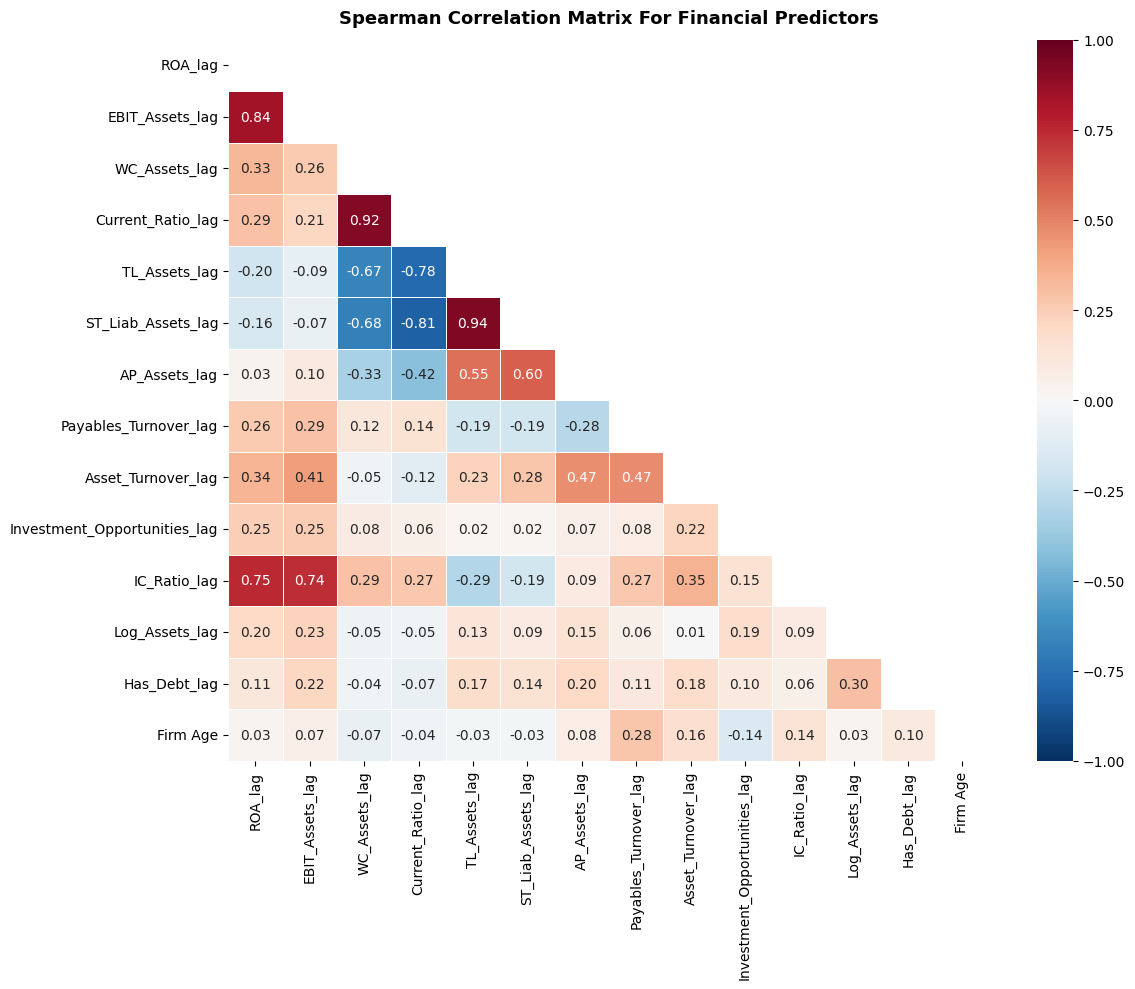

In [353]:
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Spearman Correlation Matrix For Financial Predictors',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

## **2. Prepare Analytical Sample**

In [354]:
# Rebuild ana from df_clean (now includes lags)
ana = df_clean[df_clean['Financial_Distress'].notna()].copy()

# Crisis dummies
ana['covid_dummy'] = (ana['Year'] == 2020).astype(int)
ana['war_dummy']   = (ana['Year'] == 2022).astype(int)

# Industry dummies — Other as base category
industry_dummies = pd.get_dummies(ana['Industry_Group'], prefix='ind', drop_first=False).astype(int)
industry_dummies = industry_dummies.drop(columns=['ind_Other'])
ana = pd.concat([ana, industry_dummies], axis=1)

IND_COLS = industry_dummies.columns.tolist()

print(f"Analytical sample : {len(ana):,} obs")
print(f"Unique firms      : {ana['Firm ID'].nunique():,}")
print(f"Distress rate     : {ana['Financial_Distress'].mean() * 100:.1f}%")
print(f"Industry dummies  : {IND_COLS}")

Analytical sample : 70,351 obs
Unique firms      : 18,183
Distress rate     : 13.7%
Industry dummies  : ['ind_Agriculture', 'ind_Heavy_Industry', 'ind_Infrastructure', 'ind_Light_Industry', 'ind_Trade']


## **3. Logistic Regression Main Specifications**

### M1 — Baseline (profitability + leverage + activity)

In [355]:
m1_vars = ['ROA_lag', 'TL_Assets_lag', 'Asset_Turnover_lag']

print("VIF CHECK — M1"); print("=" * 58)
check_vif(ana, m1_vars)

VIF CHECK — M1
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.23          ✓ ok
TL_Assets_lag                           1.23          ✓ ok
Asset_Turnover_lag                      1.02          ✓ ok

✓ No multicollinearity issues detected


In [356]:
m1, n1 = run_logit(ana, m1_vars)
results = {}
results['M1_Baseline'] = {'model': m1, 'n': n1}
print(f"N = {n1:,} | Pseudo R² = {m1.prsquared:.4f} | AIC = {m1.aic:.1f}")
print(); print(m1.summary2()); print()
print_ame(m1, 'M1_Baseline')

N = 63,049 | Pseudo R² = 0.1427 | AIC = 44697.0

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.143     
Date:               2026-05-02 02:03   AIC:              44696.9961
No. Observations:   63049              BIC:              44733.2028
Df Model:           3                  Log-Likelihood:   -22344.   
Df Residuals:       63045              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -2.3725   0.0322 -73.7032 0.0000 -2.4356 -2.3094
ROA_lag            -1.4178   0.0656 -21.6000 0.0000 -1.5464 -1.2891
TL_Assets_lag       0.8351

### M2 — Add liquidity

In [357]:
m2_vars = ['ROA_lag', 'WC_Assets_lag', 'TL_Assets_lag', 'Asset_Turnover_lag']

print("VIF CHECK — M2"); print("=" * 58)
check_vif(ana, m2_vars)

VIF CHECK — M2
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.24          ✓ ok
WC_Assets_lag                           5.34    ⚠ moderate
TL_Assets_lag                           5.41    ⚠ moderate
Asset_Turnover_lag                      1.02          ✓ ok

✓ No multicollinearity issues detected


In [358]:
m2, n2 = run_logit(ana, m2_vars)
results['M2_Liq'] = {'model': m2, 'n': n2}
print(f"N = {n2:,} | Pseudo R² = {m2.prsquared:.4f} | AIC = {m2.aic:.1f}")
print(); print(m2.summary2()); print()
print_ame(m2, 'M2_Liq')

N = 63,049 | Pseudo R² = 0.1437 | AIC = 44649.9

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.144     
Date:               2026-05-02 02:03   AIC:              44649.8987
No. Observations:   63049              BIC:              44695.1571
Df Model:           4                  Log-Likelihood:   -22320.   
Df Residuals:       63044              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -2.2425   0.0400 -55.9955 0.0000 -2.3210 -2.1640
ROA_lag            -1.3897   0.0662 -21.0011 0.0000 -1.5194 -1.2600
WC_Assets_lag      -0.2252

### M3 — Add trade credit (AP/Assets)

In [359]:
m3_vars = ['ROA_lag', 'WC_Assets_lag', 'TL_Assets_lag', 'Asset_Turnover_lag', 'AP_Assets_lag']

print("VIF CHECK — M3"); print("=" * 58)
check_vif(ana, m3_vars)

VIF CHECK — M3
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.24          ✓ ok
WC_Assets_lag                           5.36    ⚠ moderate
TL_Assets_lag                           5.59    ⚠ moderate
Asset_Turnover_lag                      1.08          ✓ ok
AP_Assets_lag                           1.37          ✓ ok

✓ No multicollinearity issues detected


In [360]:
m3, n3 = run_logit(ana, m3_vars)
results['M3_TradeCred'] = {'model': m3, 'n': n3}
print(f"N = {n3:,} | Pseudo R² = {m3.prsquared:.4f} | AIC = {m3.aic:.1f}")
print(); print(m3.summary2()); print()
print_ame(m3, 'M3_TradeCred')

N = 63,049 | Pseudo R² = 0.1491 | AIC = 44367.0

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.149     
Date:               2026-05-02 02:03   AIC:              44366.9600
No. Observations:   63049              BIC:              44421.2700
Df Model:           5                  Log-Likelihood:   -22177.   
Df Residuals:       63043              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -2.2818   0.0371 -61.4535 0.0000 -2.3546 -2.2090
ROA_lag            -1.3863   0.0653 -21.2180 0.0000 -1.5143 -1.2582
WC_Assets_lag      -0.1929

### M4 — Add bank debt access

In [361]:
m4_vars = ['ROA_lag', 'WC_Assets_lag', 'TL_Assets_lag', 'Asset_Turnover_lag',
           'AP_Assets_lag', 'Has_Debt_lag']

print("VIF CHECK — M4"); print("=" * 58)
check_vif(ana, m4_vars)

VIF CHECK — M4
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.24          ✓ ok
WC_Assets_lag                           5.39    ⚠ moderate
TL_Assets_lag                           5.63    ⚠ moderate
Asset_Turnover_lag                      1.08          ✓ ok
AP_Assets_lag                           1.37          ✓ ok
Has_Debt_lag                            1.01          ✓ ok

✓ No multicollinearity issues detected


In [362]:
m4, n4 = run_logit(ana, m4_vars)
results['M4_CredAccess'] = {'model': m4, 'n': n4}
print(f"N = {n4:,} | Pseudo R² = {m4.prsquared:.4f} | AIC = {m4.aic:.1f}")
print(); print(m4.summary2()); print()
print_ame(m4, 'M4_CredAccess')

N = 63,049 | Pseudo R² = 0.1553 | AIC = 44046.9

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.155     
Date:               2026-05-02 02:03   AIC:              44046.9305
No. Observations:   63049              BIC:              44110.2922
Df Model:           6                  Log-Likelihood:   -22016.   
Df Residuals:       63042              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -2.2089   0.0379 -58.2459 0.0000 -2.2832 -2.1345
ROA_lag            -1.3264   0.0652 -20.3375 0.0000 -1.4543 -1.1986
WC_Assets_lag      -0.1482

### M5 — Add size and age

In [363]:
m5_vars = ['ROA_lag', 'WC_Assets_lag', 'TL_Assets_lag', 'Asset_Turnover_lag',
           'AP_Assets_lag', 'Has_Debt_lag', 'Log_Assets_lag', 'Firm Age']

print("VIF CHECK — M5"); print("=" * 58)
check_vif(ana, m5_vars)

VIF CHECK — M5
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.30          ✓ ok
WC_Assets_lag                           5.55    ⚠ moderate
TL_Assets_lag                           5.75    ⚠ moderate
Asset_Turnover_lag                      1.14          ✓ ok
AP_Assets_lag                           1.39          ✓ ok
Has_Debt_lag                            1.12          ✓ ok
Log_Assets_lag                          1.22          ✓ ok
Firm Age                                1.04          ✓ ok

✓ No multicollinearity issues detected


In [364]:
m5, n5 = run_logit(ana, m5_vars)
results['M5_SizeAge'] = {'model': m5, 'n': n5}
print(f"N = {n5:,} | Pseudo R² = {m5.prsquared:.4f} | AIC = {m5.aic:.1f}")
print(); print(m5.summary2()); print()
print_ame(m5, 'M5_SizeAge')

N = 63,049 | Pseudo R² = 0.1564 | AIC = 43995.3

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.156     
Date:               2026-05-02 02:03   AIC:              43995.2823
No. Observations:   63049              BIC:              44076.7473
Df Model:           8                  Log-Likelihood:   -21989.   
Df Residuals:       63040              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -1.8679   0.1059 -17.6429 0.0000 -2.0754 -1.6604
ROA_lag            -1.2559   0.0690 -18.2102 0.0000 -1.3910 -1.1207
WC_Assets_lag      -0.1207

### M6 — Add industry dummies

In [365]:
m6_vars = ['ROA_lag', 'WC_Assets_lag', 'TL_Assets_lag', 'Asset_Turnover_lag',
           'AP_Assets_lag', 'Has_Debt_lag', 'Log_Assets_lag', 'Firm Age'] + IND_COLS

print("VIF CHECK — M6"); print("=" * 58)
check_vif(ana, m6_vars)

VIF CHECK — M6
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.30          ✓ ok
WC_Assets_lag                           5.65    ⚠ moderate
TL_Assets_lag                           5.82    ⚠ moderate
Asset_Turnover_lag                      1.29          ✓ ok
AP_Assets_lag                           1.48          ✓ ok
Has_Debt_lag                            1.24          ✓ ok
Log_Assets_lag                          1.28          ✓ ok
Firm Age                                1.12          ✓ ok
ind_Agriculture                         1.43          ✓ ok
ind_Heavy_Industry                      1.27          ✓ ok
ind_Infrastructure                      1.24          ✓ ok
ind_Light_Industry                      1.25          ✓ ok
ind_Trade                               1.59          ✓ ok

✓ No multicollinearity issues detected


In [366]:
m6, n6 = run_logit(ana, m6_vars)
results['M6_Ind'] = {'model': m6, 'n': n6}
print(f"N = {n6:,} | Pseudo R² = {m6.prsquared:.4f} | AIC = {m6.aic:.1f}")
print(); print(m6.summary2()); print()
print_ame(m6, 'M6_Ind')

N = 63,049 | Pseudo R² = 0.1615 | AIC = 43735.5

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.162     
Date:               2026-05-02 02:03   AIC:              43735.4917
No. Observations:   63049              BIC:              43862.2150
Df Model:           13                 Log-Likelihood:   -21854.   
Df Residuals:       63035              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -1.8514   0.1049 -17.6521 0.0000 -2.0570 -1.6458
ROA_lag            -1.2605   0.0689 -18.2824 0.0000 -1.3957 -1.1254
WC_Assets_lag      -0.1001

### M7 — Add crisis dummies

In [367]:
m7_vars = ['ROA_lag', 'WC_Assets_lag', 'TL_Assets_lag', 'Asset_Turnover_lag',
           'AP_Assets_lag', 'Has_Debt_lag', 'Log_Assets_lag',
           'covid_dummy', 'war_dummy'] + IND_COLS

print("VIF CHECK — M7"); print("=" * 58)
check_vif(ana, m7_vars)

VIF CHECK — M7
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.30          ✓ ok
WC_Assets_lag                           5.51    ⚠ moderate
TL_Assets_lag                           5.71    ⚠ moderate
Asset_Turnover_lag                      1.29          ✓ ok
AP_Assets_lag                           1.47          ✓ ok
Has_Debt_lag                            1.24          ✓ ok
Log_Assets_lag                          1.29          ✓ ok
covid_dummy                             1.06          ✓ ok
war_dummy                               1.04          ✓ ok
ind_Agriculture                         1.37          ✓ ok
ind_Heavy_Industry                      1.23          ✓ ok
ind_Infrastructure                      1.23          ✓ ok
ind_Light_Industry                      1.22          ✓ ok
ind_Trade                               1.58          ✓ ok

✓ No multicollinearity issues detected


In [368]:
m7, n7 = run_logit(ana, m7_vars)
results['M7_Crisis'] = {'model': m7, 'n': n7}
print(f"N = {n7:,} | Pseudo R² = {m7.prsquared:.4f} | AIC = {m7.aic:.1f}")
print(); print(m7.summary2()); print()
print_ame(m7, 'M7_Crisis')

N = 63,049 | Pseudo R² = 0.1651 | AIC = 43552.1

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.165     
Date:               2026-05-02 02:03   AIC:              43552.0987
No. Observations:   63049              BIC:              43687.8737
Df Model:           14                 Log-Likelihood:   -21761.   
Df Residuals:       63034              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -1.9663   0.0992 -19.8261 0.0000 -2.1607 -1.7720
ROA_lag            -1.3000   0.0698 -18.6217 0.0000 -1.4368 -1.1632
WC_Assets_lag      -0.0973

### M8 — Robustness: EBIT/Assets instead of ROA

In [369]:
m8_vars = ['EBIT_Assets_lag', 'WC_Assets_lag', 'TL_Assets_lag', 'Asset_Turnover_lag',
           'AP_Assets_lag', 'Has_Debt_lag', 'Log_Assets_lag',
           'covid_dummy', 'war_dummy'] + IND_COLS

print("VIF CHECK — M8"); print("=" * 58)
check_vif(ana, m8_vars)

VIF CHECK — M8
Variable                                 VIF        Status
----------------------------------------------------------
EBIT_Assets_lag                         1.28          ✓ ok
WC_Assets_lag                           5.53    ⚠ moderate
TL_Assets_lag                           5.65    ⚠ moderate
Asset_Turnover_lag                      1.31          ✓ ok
AP_Assets_lag                           1.48          ✓ ok
Has_Debt_lag                            1.23          ✓ ok
Log_Assets_lag                          1.29          ✓ ok
covid_dummy                             1.06          ✓ ok
war_dummy                               1.04          ✓ ok
ind_Agriculture                         1.37          ✓ ok
ind_Heavy_Industry                      1.23          ✓ ok
ind_Infrastructure                      1.23          ✓ ok
ind_Light_Industry                      1.22          ✓ ok
ind_Trade                               1.59          ✓ ok

✓ No multicollinearity issues detected


In [370]:
m8, n8 = run_logit(ana, m8_vars)
results['M8_AltProf'] = {'model': m8, 'n': n8}
print(f"N = {n8:,} | Pseudo R² = {m8.prsquared:.4f} | AIC = {m8.aic:.1f}")
print(); print(m8.summary2()); print()
print_ame(m8, 'M8_AltProf')

N = 63,048 | Pseudo R² = 0.1685 | AIC = 43373.8

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.169     
Date:               2026-05-02 02:03   AIC:              43373.8359
No. Observations:   63048              BIC:              43509.6107
Df Model:           14                 Log-Likelihood:   -21672.   
Df Residuals:       63033              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -2.0936   0.1000 -20.9454 0.0000 -2.2895 -1.8977
EBIT_Assets_lag    -1.4621   0.0704 -20.7803 0.0000 -1.6000 -1.3242
WC_Assets_lag      -0.0716

### M9 — Robustness: Current Ratio instead of WC/Assets

In [371]:
m9_vars = [
    'EBIT_Assets_lag',
    'Current_Ratio_lag',   # alternative liquidity (replaces WC_Assets)
    'TL_Assets_lag',
    'AP_Assets_lag',
    'Asset_Turnover_lag',
    'Has_Debt_lag',
    'Log_Assets_lag',
    'covid_dummy',
    'war_dummy',
] + IND_COLS

print("VIF CHECK — M9"); print("=" * 58)
check_vif(ana, m9_vars)

VIF CHECK — M9
Variable                                 VIF        Status
----------------------------------------------------------
EBIT_Assets_lag                         1.27          ✓ ok
Current_Ratio_lag                       1.18          ✓ ok
TL_Assets_lag                           1.52          ✓ ok
AP_Assets_lag                           1.47          ✓ ok
Asset_Turnover_lag                      1.34          ✓ ok
Has_Debt_lag                            1.24          ✓ ok
Log_Assets_lag                          1.30          ✓ ok
covid_dummy                             1.06          ✓ ok
war_dummy                               1.04          ✓ ok
ind_Agriculture                         1.39          ✓ ok
ind_Heavy_Industry                      1.27          ✓ ok
ind_Infrastructure                      1.26          ✓ ok
ind_Light_Industry                      1.24          ✓ ok
ind_Trade                               1.60          ✓ ok

✓ No multicollinearity issues detected


In [372]:
m9, n9 = run_logit(ana, m9_vars)
results['M9_Final'] = {'model': m9, 'n': n9}
print(f"N = {n9:,} | Pseudo R² = {m9.prsquared:.4f} | AIC = {m9.aic:.1f}")
print(); print(m9.summary2()); print()
print_ame(m9, 'M9_Final')

N = 62,033 | Pseudo R² = 0.1699 | AIC = 42869.9

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.170     
Date:               2026-05-02 02:03   AIC:              42869.9418
No. Observations:   62033              BIC:              43005.4731
Df Model:           14                 Log-Likelihood:   -21420.   
Df Residuals:       62018              LL-Null:          -25804.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -1.9269   0.1015 -18.9883 0.0000 -2.1258 -1.7280
EBIT_Assets_lag    -1.4890   0.0725 -20.5373 0.0000 -1.6311 -1.3469
Current_Ratio_lag  -0.0044

### M10 — Robustness: ST liabilities instead of TL/Assets

In [373]:
# ST liabilities as alternative leverage measure
m10_vars = [
    'EBIT_Assets_lag',
    'Current_Ratio_lag',
    'ST_Liab_Assets_lag',  # alternative leverage
    'AP_Assets_lag',
    'Asset_Turnover_lag',
    'Has_Debt_lag',
    'Log_Assets_lag',
    'covid_dummy',
    'war_dummy',
] + IND_COLS

print("VIF CHECK — M10"); print("=" * 58)
check_vif(ana, m10_vars)

VIF CHECK — M10
Variable                                 VIF        Status
----------------------------------------------------------
EBIT_Assets_lag                         1.27          ✓ ok
Current_Ratio_lag                       1.18          ✓ ok
ST_Liab_Assets_lag                      1.63          ✓ ok
AP_Assets_lag                           1.55          ✓ ok
Asset_Turnover_lag                      1.34          ✓ ok
Has_Debt_lag                            1.23          ✓ ok
Log_Assets_lag                          1.31          ✓ ok
covid_dummy                             1.06          ✓ ok
war_dummy                               1.04          ✓ ok
ind_Agriculture                         1.39          ✓ ok
ind_Heavy_Industry                      1.27          ✓ ok
ind_Infrastructure                      1.26          ✓ ok
ind_Light_Industry                      1.24          ✓ ok
ind_Trade                               1.60          ✓ ok

✓ No multicollinearity issues detected


In [374]:
m10, n10 = run_logit(ana, m10_vars)
results['M10_AltLev'] = {'model': m10, 'n': n10}
print(f"N = {n10:,} | Pseudo R² = {m10.prsquared:.4f} | AIC = {m10.aic:.1f}")
print(); print(m10.summary2()); print()
print_ame(m10, 'M10_AltLev')

N = 62,033 | Pseudo R² = 0.1632 | AIC = 43215.4

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.163     
Date:               2026-05-02 02:03   AIC:              43215.4143
No. Observations:   62033              BIC:              43350.9456
Df Model:           14                 Log-Likelihood:   -21593.   
Df Residuals:       62018              LL-Null:          -25804.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -1.9460   0.1022 -19.0380 0.0000 -2.1463 -1.7456
EBIT_Assets_lag    -1.5239   0.0724 -21.0438 0.0000 -1.6659 -1.3820
Current_Ratio_lag  -0.0044

## **4. Sensitivity Checks**

### M_IO — Add Investment Opportunities
*(N reduced — IO requires lagged PPE)*

In [375]:
mio_vars = [
    'EBIT_Assets_lag', 'Current_Ratio_lag', 'TL_Assets_lag', 'AP_Assets_lag',
    'Asset_Turnover_lag', 'Has_Debt_lag', 'Log_Assets_lag',
    'Investment_Opportunities_lag',  # sensitivity check
    'covid_dummy', 'war_dummy',
] + IND_COLS

print("VIF CHECK — M_IO"); print("=" * 58)
check_vif(ana, mio_vars)

VIF CHECK — M_IO
Variable                                 VIF        Status
----------------------------------------------------------
EBIT_Assets_lag                         1.28          ✓ ok
Current_Ratio_lag                       1.11          ✓ ok
TL_Assets_lag                           1.50          ✓ ok
AP_Assets_lag                           1.50          ✓ ok
Asset_Turnover_lag                      1.35          ✓ ok
Has_Debt_lag                            1.23          ✓ ok
Log_Assets_lag                          1.31          ✓ ok
Investment_Opportunities_lag            1.01          ✓ ok
covid_dummy                             1.09          ✓ ok
war_dummy                               1.06          ✓ ok
ind_Agriculture                         1.52          ✓ ok
ind_Heavy_Industry                      1.33          ✓ ok
ind_Infrastructure                      1.31          ✓ ok
ind_Light_Industry                      1.29          ✓ ok
ind_Trade                              

In [376]:
mio, nio = run_logit(ana, mio_vars)
results['M_IO_Sensitivity'] = {'model': mio, 'n': nio}
print(f"⚠ Note: N reduced to {nio:,} (Investment_Opportunities requires lagged PPE)")
print(f"N = {nio:,} | Pseudo R² = {mio.prsquared:.4f} | AIC = {mio.aic:.1f}")
print(); print(mio.summary2()); print()
print_ame(mio, 'M_IO_Sensitivity')

⚠ Note: N reduced to 38,369 (Investment_Opportunities requires lagged PPE)
N = 38,369 | Pseudo R² = 0.1774 | AIC = 26440.8

                               Results: Logit
Model:                  Logit                 Method:              MLE       
Dependent Variable:     Financial_Distress    Pseudo R-squared:    0.177     
Date:                   2026-05-02 02:03      AIC:                 26440.8055
No. Observations:       38369                 BIC:                 26577.6855
Df Model:               15                    Log-Likelihood:      -13204.   
Df Residuals:           38353                 LL-Null:             -16053.   
Converged:              1.0000                LLR p-value:         0.0000    
No. Iterations:         7.0000                Scale:               1.0000    
-----------------------------------------------------------------------------
                              Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
--------------------------------------------------

### M_IC — Add Interest Coverage Ratio
*(N reduced — IC requires Financial Expenses > 0)*

In [377]:
mic_vars = [
    'EBIT_Assets_lag', 'Current_Ratio_lag', 'TL_Assets_lag', 'AP_Assets_lag',
    'Asset_Turnover_lag', 'Has_Debt_lag', 'Log_Assets_lag',
    'IC_Ratio_lag',  # sensitivity check
    'covid_dummy', 'war_dummy',
] + IND_COLS

print("VIF CHECK — M_IC"); print("=" * 58)
check_vif(ana, mic_vars)

VIF CHECK — M_IC
Variable                                 VIF        Status
----------------------------------------------------------
EBIT_Assets_lag                         1.30          ✓ ok
Current_Ratio_lag                       1.17          ✓ ok
TL_Assets_lag                           1.27          ✓ ok
AP_Assets_lag                           1.38          ✓ ok
Asset_Turnover_lag                      1.46          ✓ ok
Has_Debt_lag                            1.29          ✓ ok
Log_Assets_lag                          1.18          ✓ ok
IC_Ratio_lag                            1.20          ✓ ok
covid_dummy                             1.07          ✓ ok
war_dummy                               1.04          ✓ ok
ind_Agriculture                         1.91          ✓ ok
ind_Heavy_Industry                      1.56          ✓ ok
ind_Infrastructure                      1.50          ✓ ok
ind_Light_Industry                      1.56          ✓ ok
ind_Trade                              

In [378]:
mic, nic = run_logit(ana, mic_vars)
results['M_IC_Sensitivity'] = {'model': mic, 'n': nic}
print(f"⚠ Note: N reduced to {nic:,} (IC_Ratio requires Financial Expenses > 0)")
print(f"N = {nic:,} | Pseudo R² = {mic.prsquared:.4f} | AIC = {mic.aic:.1f}")
print(); print(mic.summary2()); print()
print_ame(mic, 'M_IC_Sensitivity')

⚠ Note: N reduced to 25,474 (IC_Ratio requires Financial Expenses > 0)
N = 25,474 | Pseudo R² = 0.1700 | AIC = 15428.1

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.170     
Date:               2026-05-02 02:03   AIC:              15428.1216
No. Observations:   25474              BIC:              15558.4482
Df Model:           15                 Log-Likelihood:   -7698.1   
Df Residuals:       25458              LL-Null:          -9275.3   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -2.4619   0.1947 -12.6441 0.0000 -2.8435 -2.0803
EBIT_Assets_lag    -1.5

### M_PT — Payables Turnover instead of AP/Assets

In [379]:
mpt_vars = [
    'EBIT_Assets_lag', 'Current_Ratio_lag', 'TL_Assets_lag',
    'Payables_Turnover_lag',  # replaces AP_Assets_lag
    'Asset_Turnover_lag', 'Has_Debt_lag', 'Log_Assets_lag',
    'covid_dummy', 'war_dummy',
] + IND_COLS

print("VIF CHECK — M_PT"); print("=" * 58)
check_vif(ana, mpt_vars)

VIF CHECK — M_PT
Variable                                 VIF        Status
----------------------------------------------------------
EBIT_Assets_lag                         1.26          ✓ ok
Current_Ratio_lag                       1.17          ✓ ok
TL_Assets_lag                           1.26          ✓ ok
Payables_Turnover_lag                   1.06          ✓ ok
Asset_Turnover_lag                      1.37          ✓ ok
Has_Debt_lag                            1.22          ✓ ok
Log_Assets_lag                          1.28          ✓ ok
covid_dummy                             1.06          ✓ ok
war_dummy                               1.04          ✓ ok
ind_Agriculture                         1.45          ✓ ok
ind_Heavy_Industry                      1.31          ✓ ok
ind_Infrastructure                      1.28          ✓ ok
ind_Light_Industry                      1.27          ✓ ok
ind_Trade                               1.64          ✓ ok

✓ No multicollinearity issues detected

In [380]:
mpt, npt = run_logit(ana, mpt_vars)
results['M_PT_Sensitivity'] = {'model': mpt, 'n': npt}
print(f"⚠ Note: N reduced to {npt:,} (Payables_Turnover requires AP > 0)")
print(f"N = {npt:,} | Pseudo R² = {mpt.prsquared:.4f} | AIC = {mpt.aic:.1f}")
print(); print(mpt.summary2()); print()
print_ame(mpt, 'M_PT_Sensitivity')

⚠ Note: N reduced to 54,960 (Payables_Turnover requires AP > 0)
N = 54,960 | Pseudo R² = 0.1716 | AIC = 38239.3

                            Results: Logit
Model:               Logit               Method:            MLE       
Dependent Variable:  Financial_Distress  Pseudo R-squared:  0.172     
Date:                2026-05-02 02:03    AIC:               38239.2896
No. Observations:    54960               BIC:               38373.0050
Df Model:            14                  Log-Likelihood:    -19105.   
Df Residuals:        54945               LL-Null:           -23061.   
Converged:           1.0000              LLR p-value:       0.0000    
No. Iterations:      7.0000              Scale:             1.0000    
----------------------------------------------------------------------
                       Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
----------------------------------------------------------------------
const                 -1.8606   0.1135 -16.3976 0.0000 -2.0830 

## **5. Robustness: Active Firms Only**

In [381]:
# Keep only active firms to check whether results are driven by firms near exit
ceased_statuses = ['Не перебуває в процесі припинення']
active_firms    = df_clean[df_clean['Firm Status (Latest)'].isin(ceased_statuses)]['Firm ID'].unique()
ana_active      = ana[ana['Firm ID'].isin(active_firms)].copy()

print(f"N observations : {len(ana_active):,}")
print(f"N unique firms : {ana_active['Firm ID'].nunique():,}")
print(f"Distress rate  : {ana_active['Financial_Distress'].mean()*100:.1f}%")

N observations : 65,115
N unique firms : 16,491
Distress rate  : 12.6%


In [382]:
model_active, n_active = run_logit(ana_active, m9_vars)
print(f"N = {n_active:,} | Pseudo R² = {model_active.prsquared:.4f} | AIC = {model_active.aic:.1f}")
print(); print(model_active.summary()); print()
print_ame(model_active, 'M9 — Active Firms Only')

N = 57,438 | Pseudo R² = 0.1712 | AIC = 37496.5

                           Logit Regression Results                           
Dep. Variable:     Financial_Distress   No. Observations:                57438
Model:                          Logit   Df Residuals:                    57423
Method:                           MLE   Df Model:                           14
Date:                Sat, 02 May 2026   Pseudo R-squ.:                  0.1712
Time:                        02:03:53   Log-Likelihood:                -18733.
converged:                       True   LL-Null:                       -22602.
Covariance Type:              cluster   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.8797      0.108    -17.349      0.000      -2.092      -1.667
EBIT_Assets_lag       -1.3970      0.076    -18.431      0

## **6. Industry-Specific Models**

In [383]:
# M9 specification without industry dummies (running within each industry)
m9_base = [v for v in m9_vars if v not in IND_COLS]

industries = sorted(ana['Industry_Group'].unique())

for industry in industries:
    ana_ind = ana[ana['Industry_Group'] == industry].copy()
    n_ind   = len(ana_ind)
    n_dist  = (ana_ind['Financial_Distress'] == 1).sum()

    print(f"\n{'='*70}")
    print(f"INDUSTRY: {industry}")
    print(f"N = {n_ind:,}  |  Distress = {n_dist:,} ({n_dist/n_ind*100:.1f}%)")
    print(f"{'='*70}")

    try:
        model, n = run_logit(ana_ind, m9_base)
        print(f"N = {n:,} | Pseudo R² = {model.prsquared:.4f} | "
              f"AIC = {model.aic:.1f} | Converged = {model.mle_retvals['converged']}")
        print()
        print(f"{'Variable':<30} {'Coef':>10}  {'Std Err':>10}  {'z':>8}  {'p-value':>10}  {'Sig':>5}")
        print("-" * 70)
        for var in model.params.index:
            coef = model.params[var]
            se   = model.bse[var]
            z    = model.tvalues[var]
            p    = model.pvalues[var]
            sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            print(f"{var:<30} {coef:>10.4f}  {se:>10.4f}  {z:>8.3f}  {p:>10.4f}  {sig:>5}")
        print_ame(model, f'M9 — {industry}')
    except Exception as e:
        print(f"✗ Failed: {e}")


INDUSTRY: Agriculture
N = 10,689  |  Distress = 1,045 (9.8%)


N = 10,232 | Pseudo R² = 0.1878 | AIC = 5379.6 | Converged = True

Variable                             Coef     Std Err         z     p-value    Sig
----------------------------------------------------------------------
const                             -3.1077      0.3640    -8.538      0.0000    ***
EBIT_Assets_lag                   -2.0459      0.2773    -7.377      0.0000    ***
Current_Ratio_lag                 -0.0076      0.0028    -2.750      0.0060     **
TL_Assets_lag                      1.1037      0.1237     8.925      0.0000    ***
AP_Assets_lag                      0.8351      0.2073     4.029      0.0001    ***
Asset_Turnover_lag                -0.2907      0.0666    -4.366      0.0000    ***
Has_Debt_lag                      -0.5516      0.0892    -6.184      0.0000    ***
Log_Assets_lag                     0.0574      0.0292     1.966      0.0493      *
covid_dummy                        0.2616      0.1570     1.666      0.0957     ns
war_dummy                       

## **7. Crisis Period Models**

In [384]:
# M9 without crisis dummies — running separately for each year
m9_crisis_vars = [v for v in m9_vars if v not in ['covid_dummy', 'war_dummy']]

subperiods = {
    'Pre-crisis (2019)': ana[ana['Year'] == 2019].copy(),
    'COVID (2020)'     : ana[ana['Year'] == 2020].copy(),
    'War (2022)'       : ana[ana['Year'] == 2022].copy(),
}

for period_name, ana_sub in subperiods.items():
    n_sub  = len(ana_sub)
    n_dist = (ana_sub['Financial_Distress'] == 1).sum()

    print(f"\n{'='*70}")
    print(f"SUBPERIOD: {period_name}")
    print(f"N = {n_sub:,}  |  Distress = {n_dist:,} ({n_dist/n_sub*100:.1f}%)")
    print(f"{'='*70}")

    try:
        model, n = run_logit(ana_sub, m9_crisis_vars)
        print(f"N = {n:,} | Pseudo R² = {model.prsquared:.4f} | "
              f"AIC = {model.aic:.1f} | Converged = {model.mle_retvals['converged']}")
        print()
        print(f"{'Variable':<30} {'Coef':>10}  {'Std Err':>10}  {'z':>8}  {'p-value':>10}  {'Sig':>5}")
        print("-" * 70)
        for var in model.params.index:
            coef = model.params[var]
            se   = model.bse[var]
            z    = model.tvalues[var]
            p    = model.pvalues[var]
            sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            print(f"{var:<30} {coef:>10.4f}  {se:>10.4f}  {z:>8.3f}  {p:>10.4f}  {sig:>5}")
        print_ame(model, f'M9 — {period_name}')
    except Exception as e:
        print(f"✗ Failed: {e}")


SUBPERIOD: Pre-crisis (2019)
N = 12,528  |  Distress = 1,661 (13.3%)
N = 10,828 | Pseudo R² = 0.1550 | AIC = 7399.7 | Converged = True

Variable                             Coef     Std Err         z     p-value    Sig
----------------------------------------------------------------------
const                             -2.3175      0.2004   -11.564      0.0000    ***
EBIT_Assets_lag                   -1.9891      0.1798   -11.062      0.0000    ***
Current_Ratio_lag                  0.0000      0.0014     0.009      0.9927     ns
TL_Assets_lag                      0.5791      0.0575    10.068      0.0000    ***
AP_Assets_lag                      0.8669      0.1152     7.528      0.0000    ***
Asset_Turnover_lag                -0.0864      0.0223    -3.876      0.0001    ***
Has_Debt_lag                      -0.2217      0.0771    -2.874      0.0041     **
Log_Assets_lag                    -0.0156      0.0182    -0.859      0.3905     ns
ind_Agriculture                    0.2731    

## **8. Prediction**

### 8.1 Train / test split
Train: 2019–2022 | Test: 2023–2024

In [385]:
train = ana[ana['Year'] <= 2022][m9_base + ['Financial_Distress', 'Firm ID', 'Year']].dropna().copy()
test  = ana[ana['Year'] >= 2023][m9_base + ['Financial_Distress', 'Firm ID', 'Year']].dropna().copy()

print("TRAIN / TEST SPLIT"); print("=" * 50)
print(f"  Train (2019–2022) : {len(train):,} obs  |  Distress rate: {train['Financial_Distress'].mean()*100:.1f}%")
print(f"  Test  (2023–2024) : {len(test):,} obs  |  Distress rate: {test['Financial_Distress'].mean()*100:.1f}%")

TRAIN / TEST SPLIT
  Train (2019–2022) : 40,986 obs  |  Distress rate: 15.2%
  Test  (2023–2024) : 21,047 obs  |  Distress rate: 13.5%


### 8.2 Logit prediction

In [386]:
# ═══════════════════════════════════════════════════════════
# CELL · LOGIT PREDICTION — M9
# ═══════════════════════════════════════════════════════════


X_train   = sm.add_constant(train[m9_base])
y_train   = train['Financial_Distress']
grp_train = train['Firm ID']

logit_train = sm.Logit(y_train, X_train).fit(
    cov_type='cluster',
    cov_kwds={'groups': grp_train},
    maxiter=200, disp=False
)

X_test = sm.add_constant(test[m9_base])
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_test = test['Financial_Distress']

# Predicted probabilities
probs_train = logit_train.predict(X_train)
probs_test  = logit_train.predict(X_test)

# Optimal threshold — найдений на TRAIN (не на test!)
thresholds  = np.linspace(0.05, 0.95, 100)
f1_train    = [f1_score(y_train, probs_train > t, zero_division=0)
               for t in thresholds]
opt_t       = thresholds[np.argmax(f1_train)]

# Apply optimal threshold to TEST
y_pred = (probs_test > opt_t).astype(int)
cm     = confusion_matrix(y_test, y_pred)

print("LOGIT M9 — PREDICTION RESULTS")
print("=" * 55)
print(f"  Optimal threshold  : {opt_t:.3f}")
print()
print(f"  AUC-ROC            : {roc_auc_score(y_test, probs_test):.4f}")
print(f"  F1-Score           : {f1_score(y_test, y_pred):.4f}")
print(f"  Precision          : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall             : {recall_score(y_test, y_pred):.4f}")
print()
print("CONFUSION MATRIX:")
print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")

LOGIT M9 — PREDICTION RESULTS
  Optimal threshold  : 0.205

  AUC-ROC            : 0.8086
  F1-Score           : 0.5136
  Precision          : 0.5806
  Recall             : 0.4606

CONFUSION MATRIX:
  TN=17,262  FP=945
  FN=1,532  TP=1,308


### 8.3 Logit ROC curve

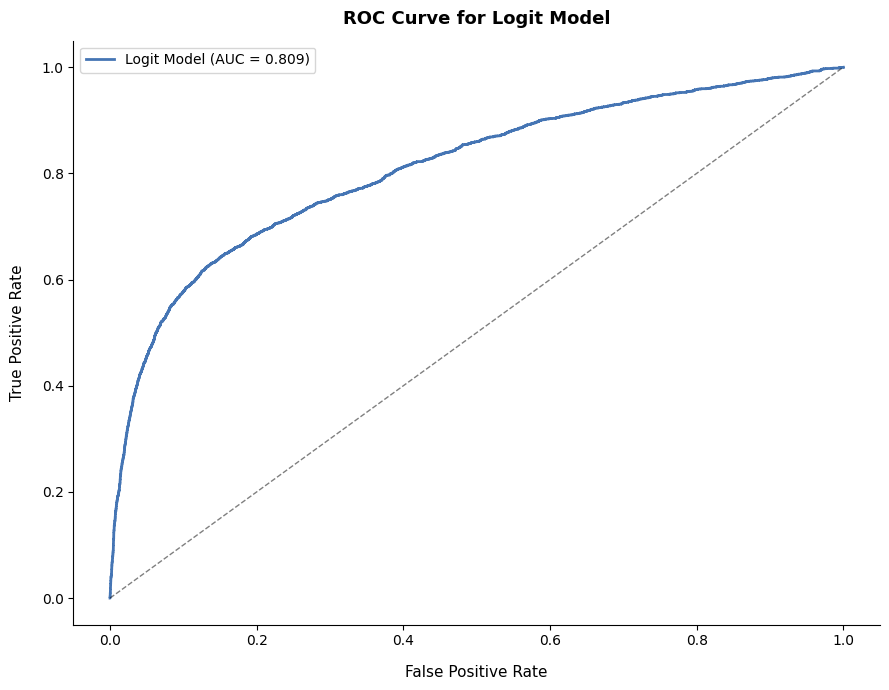

In [387]:
fig, ax = plt.subplots(figsize=(9, 7))
fpr, tpr, _ = roc_curve(y_test, probs_test)
auc_score   = roc_auc_score(y_test, probs_test)

ax.plot(fpr, tpr, color='#4575b4', lw=2, label=f'Logit Model (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=11, labelpad=12)
ax.set_ylabel('True Positive Rate', fontsize=11, labelpad=12)
ax.set_title('ROC Curve for Logit Model', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10); ax.spines[['top', 'right']].set_visible(False); ax.grid(False)
plt.tight_layout(); plt.show()

## **9. Random Forest**

### 9.1 Sample preparation

In [388]:
rf_vars = m9_base.copy()

# Sort train by Year for TimeSeriesSplit
train_rf = train[rf_vars + ['Financial_Distress', 'Year']].dropna().sort_values('Year').copy()
test_rf  = test[rf_vars + ['Financial_Distress']].dropna().copy()

X_train_rf = train_rf[rf_vars].values
y_train_rf = train_rf['Financial_Distress'].values
X_test_rf  = test_rf[rf_vars].values
y_test_rf  = test_rf['Financial_Distress'].values

print("RANDOM FOREST — SAMPLE"); print("=" * 50)
print(f"  Train (2019–2022) : {len(train_rf):,} obs  |  Distress: {y_train_rf.mean()*100:.1f}%")
print(f"  Test  (2023–2024) : {len(test_rf):,} obs   |  Distress: {y_test_rf.mean()*100:.1f}%")
print(f"  Features          : {len(rf_vars)}")

RANDOM FOREST — SAMPLE
  Train (2019–2022) : 40,986 obs  |  Distress: 15.2%
  Test  (2023–2024) : 21,047 obs   |  Distress: 13.5%
  Features          : 9


### 9.2 Hyperparameter tuning

In [389]:
# TimeSeriesSplit preserves temporal order in cross-validation
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators'    : [100, 300, 500],
    'max_depth'       : [4, 6, 8],
    'min_samples_leaf': [50, 100, 200],
    'class_weight'    : ['balanced'],
}

rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
rf_cv.fit(X_train_rf, y_train_rf)

print(f"Best params : {rf_cv.best_params_}")
print(f"Best CV AUC : {rf_cv.best_score_:.4f}")

rf_best = rf_cv.best_estimator_

Best params : {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 50, 'n_estimators': 500}
Best CV AUC : 0.8374


### 9.3 Prediction and overfitting check

In [390]:
probs_train_rf = rf_best.predict_proba(X_train_rf)[:, 1]
probs_test_rf  = rf_best.predict_proba(X_test_rf)[:, 1]

train_auc_rf = roc_auc_score(y_train_rf, probs_train_rf)
test_auc_rf  = roc_auc_score(y_test_rf,  probs_test_rf)

print("OVERFITTING CHECK"); print("=" * 40)
print(f"  Train AUC : {train_auc_rf:.4f}")
print(f"  Test AUC  : {test_auc_rf:.4f}")
print(f"  Gap       : {train_auc_rf - test_auc_rf:.4f} "
      f"({'⚠ overfitting' if train_auc_rf - test_auc_rf > 0.05 else '✓ ok'})")

# Optimal threshold on TRAIN
f1_train_rf = [f1_score(y_train_rf, probs_train_rf > t, zero_division=0) for t in thresholds]
opt_t_rf    = thresholds[np.argmax(f1_train_rf)]

y_pred_rf = (probs_test_rf > opt_t_rf).astype(int)
cm_rf     = confusion_matrix(y_test_rf, y_pred_rf)

print()
print("RANDOM FOREST — PREDICTION RESULTS"); print("=" * 55)
print(f"  Optimal threshold  : {opt_t_rf:.3f}")
print()
print(f"  AUC-ROC            : {test_auc_rf:.4f}")
print(f"  F1-Score           : {f1_score(y_test_rf, y_pred_rf):.4f}")
print(f"  Precision          : {precision_score(y_test_rf, y_pred_rf):.4f}")
print(f"  Recall             : {recall_score(y_test_rf, y_pred_rf):.4f}")
print()
print("CONFUSION MATRIX:")
print(f"  TN={cm_rf[0,0]:,}  FP={cm_rf[0,1]:,}")
print(f"  FN={cm_rf[1,0]:,}  TP={cm_rf[1,1]:,}")

OVERFITTING CHECK
  Train AUC : 0.8643
  Test AUC  : 0.8710
  Gap       : -0.0067 (✓ ok)

RANDOM FOREST — PREDICTION RESULTS
  Optimal threshold  : 0.605

  AUC-ROC            : 0.8710
  F1-Score           : 0.5862
  Precision          : 0.5500
  Recall             : 0.6275

CONFUSION MATRIX:
  TN=16,749  FP=1,458
  FN=1,058  TP=1,782


### 9.4 Random Forest ROC curve

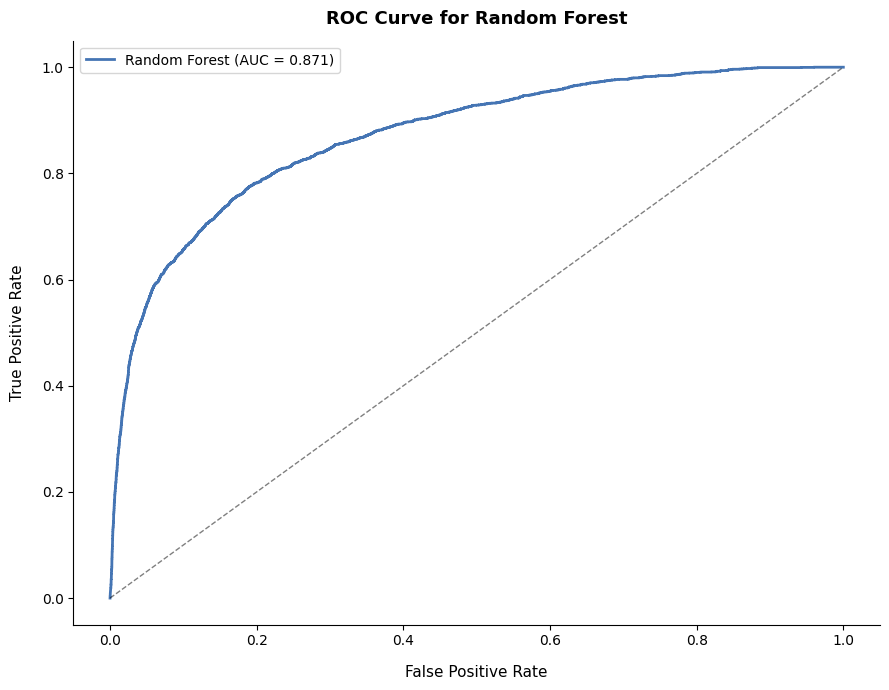

In [391]:
fig, ax = plt.subplots(figsize=(9, 7))
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, probs_test_rf)
auc_score_rf      = roc_auc_score(y_test_rf, probs_test_rf)

ax.plot(fpr_rf, tpr_rf, color='#4575b4', lw=2, label=f'Random Forest (AUC = {auc_score_rf:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=11, labelpad=12)
ax.set_ylabel('True Positive Rate', fontsize=11, labelpad=12)
ax.set_title('ROC Curve for Random Forest', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10); ax.spines[['top', 'right']].set_visible(False); ax.grid(False)
plt.tight_layout(); plt.show()

### 9.5 Feature importance

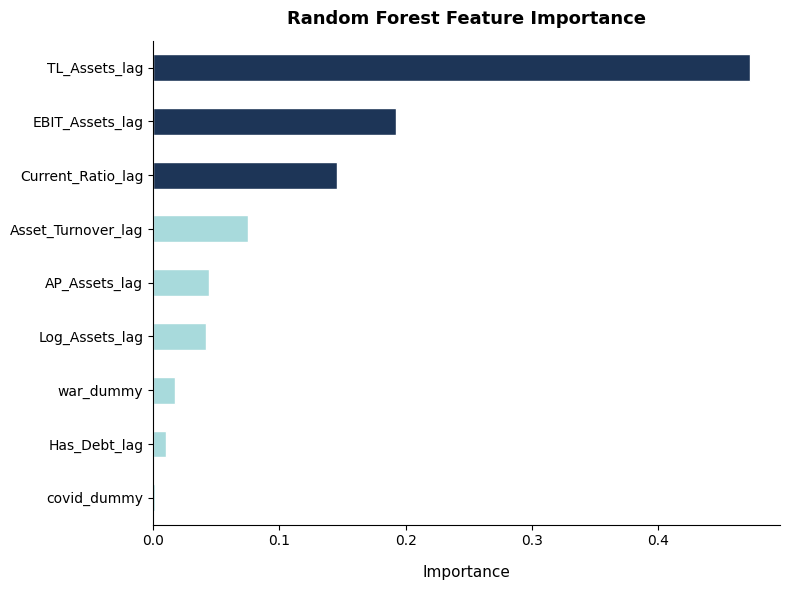

In [392]:
importances = rf_best.feature_importances_
feat_imp = pd.Series(importances, index=rf_vars).sort_values(ascending=True)

# Top-3 features highlighted in dark blue
colors = ['#1d3557' if i >= len(feat_imp) - 3 else '#a8dadc' for i in range(len(feat_imp))]

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Random Forest Feature Importance', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importance', fontsize=11, labelpad=12)
ax.spines[['top', 'right']].set_visible(False); ax.grid(False)
plt.tight_layout(); plt.show()

## **10. Model Comparison**

### 10.1 Comparison table

In [393]:
comparison = pd.DataFrame([
    {
        'Model'    : 'Logit M9',
        'AUC-ROC'  : roc_auc_score(y_test, probs_test),
        'F1-Score' : f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'Threshold': opt_t,
    },
    {
        'Model'    : 'Random Forest',
        'AUC-ROC'  : test_auc_rf,
        'F1-Score' : f1_score(y_test_rf, y_pred_rf),
        'Precision': precision_score(y_test_rf, y_pred_rf),
        'Recall'   : recall_score(y_test_rf, y_pred_rf),
        'Threshold': opt_t_rf,
    },
])

print("MODELS COMPARISON — LOGIT vs RANDOM FOREST"); print("=" * 65)
print(comparison.to_string(index=False, float_format='{:.4f}'.format))
print()
print(f"Best AUC : {comparison.loc[comparison['AUC-ROC'].idxmax(), 'Model']}")
print(f"Best F1  : {comparison.loc[comparison['F1-Score'].idxmax(), 'Model']}")

MODELS COMPARISON — LOGIT vs RANDOM FOREST
        Model  AUC-ROC  F1-Score  Precision  Recall  Threshold
     Logit M9   0.8086    0.5136     0.5806  0.4606     0.2045
Random Forest   0.8710    0.5862     0.5500  0.6275     0.6045

Best AUC : Random Forest
Best F1  : Random Forest


### 10.2 ROC curves for Logit and Random Forest

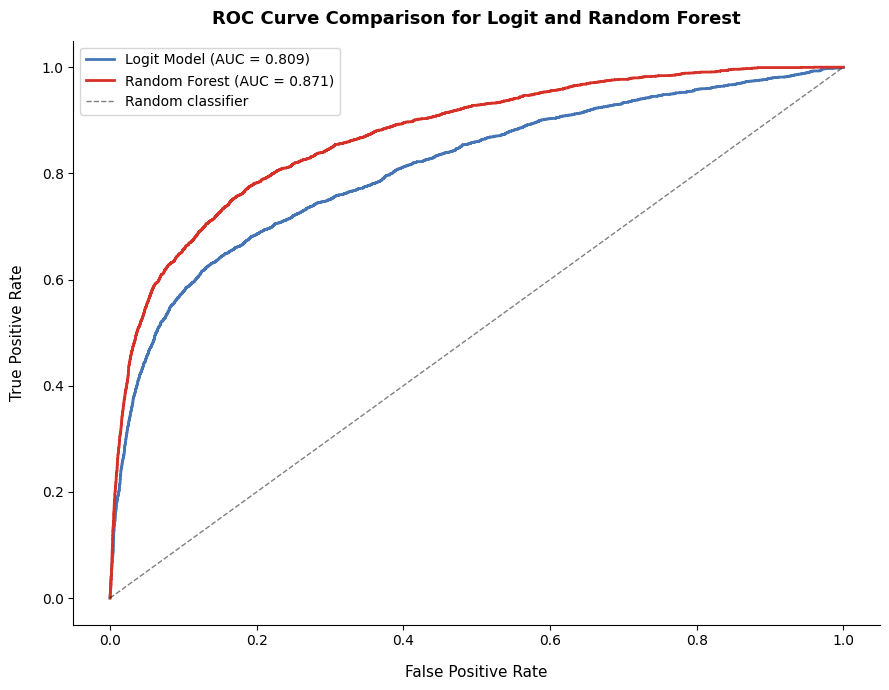

In [394]:
fig, ax = plt.subplots(figsize=(9, 7))

fpr_logit, tpr_logit, _ = roc_curve(y_test,    probs_test)
fpr_rf,    tpr_rf,    _ = roc_curve(y_test_rf,  probs_test_rf)
auc_logit = roc_auc_score(y_test,   probs_test)
auc_rf    = roc_auc_score(y_test_rf, probs_test_rf)

ax.plot(fpr_logit, tpr_logit, color='#4575b4', lw=2, label=f'Logit Model (AUC = {auc_logit:.3f})')
ax.plot(fpr_rf,    tpr_rf,    color='#d73027', lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random classifier')

ax.set_xlabel('False Positive Rate', fontsize=11, labelpad=12)
ax.set_ylabel('True Positive Rate', fontsize=11, labelpad=12)
ax.set_title('ROC Curve Comparison for Logit and Random Forest', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10); ax.spines[['top', 'right']].set_visible(False); ax.grid(False)
plt.tight_layout(); plt.show()